In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import importlib
import dataset
from image_builder import *
from data_prepare import *
import data_fetch
from data_fetch import *
from data_fetch import _download_single, _read_mops_csv

importlib.reload(dataset)
importlib.reload(data_fetch)

<module 'data_fetch' from 'c:\\Users\\user\\Desktop\\reimaging price trends\\trend_submit\\practice_file\\data_fetch.py'>

In [ ]:
from pathlib import Path

START = "2006-01-01"
END = "2025-12-31"
SAVE_DIR = "data"
Market = "US"

ticker_cache_path, excluded_path = get_ticker_cache_paths(
    save_dir=SAVE_DIR,
    Market=Market,
    start=START,
    end=END,
)

ticker_cache_path = Path(ticker_cache_path)
excluded_path = Path(excluded_path)

if ticker_cache_path.exists():
    print(f"讀取已儲存美股 ticker 清單: {ticker_cache_path}")
    ticker_df = pd.read_csv(ticker_cache_path)
    TICKERS = ticker_df["ticker"].tolist()

else:
    print("第一次建立美股 ticker 清單，會花比較久...")

    TICKERS, eligible_info, excluded = get_eligible_us_tickers(
        start=START,
        end=END,
        include_nasdaq=True,
        include_nyse=True,
        include_amex=True,
        common_stock_only=True,
        start_tolerance_days=10,
        end_tolerance_days=10,
        max_workers=8,
    )

    ticker_cache_path.parent.mkdir(parents=True, exist_ok=True)

    eligible_info.to_csv(ticker_cache_path, index=False, encoding="utf-8-sig")
    excluded.to_csv(excluded_path, index=False, encoding="utf-8-sig")

    print(f"已儲存可用美股 ticker 清單: {ticker_cache_path}")
    print(f"已儲存排除清單: {excluded_path}")

print("可用美股數量:", len(TICKERS))
print(TICKERS[:20])


第一次建立美股 ticker 清單，會花比較久...


filter tickers:   0%|          | 1/5492 [00:01<1:34:53,  1.04s/it]$AIB: possibly delisted; no price data found  (1d 2006-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1136091600, endDate = 1767157200")

1 Failed download:

1 Failed download:

1 Failed download:

1 Failed download:

1 Failed download:

1 Failed download:

1 Failed download:

1 Failed download:
['AIB']: possibly delisted; no price data found  (1d 2006-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1136091600, endDate = 1767157200")
['AIB']: possibly delisted; no price data found  (1d 2006-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1136091600, endDate = 1767157200")
['AIB']: possibly delisted; no price data found  (1d 2006-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1136091600, endDate = 1767157200")
['AIB']: possibly delisted; no price data found  (1d 2006-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for

In [30]:
from dataset import get_eligible_tw_tickers
from pathlib import Path
import pandas as pd

START = "2006-01-01"
END = "2025-12-31"

ticker_cache_path = Path("data") / f"TW_tickers_{START}_{END}.csv"

if ticker_cache_path.exists():
    print(f"讀取已儲存 ticker 清單: {ticker_cache_path}")
    ticker_cache = pd.read_csv(ticker_cache_path)
    TICKERS = ticker_cache["ticker"].tolist()

else:
    print("第一次建立 ticker 清單，會花比較久...")
    
    TICKERS, eligible_info, excluded = get_eligible_tw_tickers(
    start=START,
    end=END,
    include_listed=True,
    include_otc=True,
    max_workers=8,
)

    ticker_cache_path.parent.mkdir(parents=True, exist_ok=True)

    eligible_info.to_csv(ticker_cache_path, index=False, encoding="utf-8-sig")
    excluded.to_csv(
        Path("data") / f"TW_tickers_excluded_{START}_{END}.csv",
        index=False,
        encoding="utf-8-sig",
    )

    print(f"已儲存可用 ticker 清單: {ticker_cache_path}")

print("可用股票數:", len(TICKERS))
print(TICKERS[:10])

讀取已儲存 ticker 清單: data\TW_tickers_2006-01-01_2025-12-31.csv
可用股票數: 193
['1445.TW', '1446.TW', '1533.TW', '1587.TW', '1589.TW', '1590.TW', '1817.TW', '1903.TW', '1904.TW', '1905.TW']


In [31]:
TICKERS = TICKERS[:5]
START     = "2006-01-01"
END       = "2025-12-31"
I, R      = 5, 5
TRAIN_END = "2020-01-01"
SAVE_DIR  = "data"
Market = 'TW'
X_train, y_train, X_val, y_val, X_test, y_test, meta = build_research_dataset(
    tickers=TICKERS,
    start=START,
    end=END,
    I=I,
    R=R,
    train_end=TRAIN_END,
    save_dir=SAVE_DIR,
    Market=Market,
)



[I5/R5] 處理: 1445.TW


  生成圖像: 100%|██████████| 4899/4899 [00:21<00:00, 224.01it/s]



[I5/R5] 處理: 1446.TW


  生成圖像: 100%|██████████| 4899/4899 [00:23<00:00, 206.45it/s]



[I5/R5] 處理: 1533.TW


...


[I5/R5] 處理: 1587.TW


  生成圖像: 100%|██████████| 3296/3296 [00:14<00:00, 227.18it/s]



[I5/R5] 處理: 1589.TW


  生成圖像: 100%|██████████| 3336/3336 [00:15<00:00, 214.23it/s]



總樣本數: 21329
標籤分布: up=0.462, down=0.538
Train+Val 樣本: 14054 | Test 樣本: 7275
  Train: 9837  (up=0.461)
  Val  : 4217  (up=0.461)
  Test : 7275  (up=0.465)

✅ 已儲存至 data\training_data\TW\I5R5/


In [34]:
train_loader, val_loader, test_loader = dataset.make_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=128
)

# 3. 驗證一下載入的資料維度
sample_img, sample_label = next(iter(train_loader))
print(f"影像 Tensor 維度: {sample_img.shape}") 
# 預期輸出: torch.Size([128, 1, 64, 60]) -> [Batch, Channel, Height, Width]

影像 Tensor 維度: torch.Size([128, 1, 32, 15])


In [41]:
import model
from model import *
importlib.reload(model)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if I == 5:
    model = CNN_I5().to(device)
elif I == 20:
    model = CNN_I20().to(device)

# 定義損失函數和優化器
criterion = nn.CrossEntropyLoss()  # 交叉熵損失
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)  # Adam 優化器

# 使用 ReduceLROnPlateau 調整學習率
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)

Using device: cuda


In [42]:
# 儲存最佳驗證準確度
best_val_acc = 0.0
patience = 10  # 幾次沒進步就停止
trigger_times = 0

epochs = 50

# 用於儲存繪圖數據
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(epochs):
    # --- 訓練階段 ---
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # --- 驗證階段 ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # 計算平均值
    epoch_train_loss = train_loss / len(train_loader)
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = 100 * val_correct / val_total
    
    # 紀錄到 history
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    # 學習率調整
    scheduler.step(epoch_val_loss)

    # 儲存最佳模型
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), f'best_model_I{I}R{R}.pth')
        trigger_times = 0  # Reset patience counter
    else:
        trigger_times += 1

    # 輸出訓練過程中的損失和準確度
    print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%')

    # 檢查是否達到早期停止條件
    if trigger_times >= patience:
        print("Early stopping: No improvement in validation accuracy.")
        break

Epoch [1/50] | Train Loss: 0.7676 | Val Loss: 0.7800 | Val Acc: 47.62%
Epoch [2/50] | Train Loss: 0.7441 | Val Loss: 0.7021 | Val Acc: 51.67%
Epoch [3/50] | Train Loss: 0.7230 | Val Loss: 0.7416 | Val Acc: 53.76%
Epoch [4/50] | Train Loss: 0.7110 | Val Loss: 0.7009 | Val Acc: 52.72%
Epoch [5/50] | Train Loss: 0.7071 | Val Loss: 0.7451 | Val Acc: 48.33%
Epoch [6/50] | Train Loss: 0.6912 | Val Loss: 0.7031 | Val Acc: 51.79%
Epoch [7/50] | Train Loss: 0.6947 | Val Loss: 0.7066 | Val Acc: 53.28%
Epoch [8/50] | Train Loss: 0.6798 | Val Loss: 0.7192 | Val Acc: 53.36%
Epoch [9/50] | Train Loss: 0.6853 | Val Loss: 0.7537 | Val Acc: 47.78%
Epoch [10/50] | Train Loss: 0.6731 | Val Loss: 0.7354 | Val Acc: 48.83%
Epoch [11/50] | Train Loss: 0.6460 | Val Loss: 0.7074 | Val Acc: 51.27%
Epoch [12/50] | Train Loss: 0.6430 | Val Loss: 0.7076 | Val Acc: 52.72%
Epoch [13/50] | Train Loss: 0.6413 | Val Loss: 0.7069 | Val Acc: 52.00%
Early stopping: No improvement in validation accuracy.


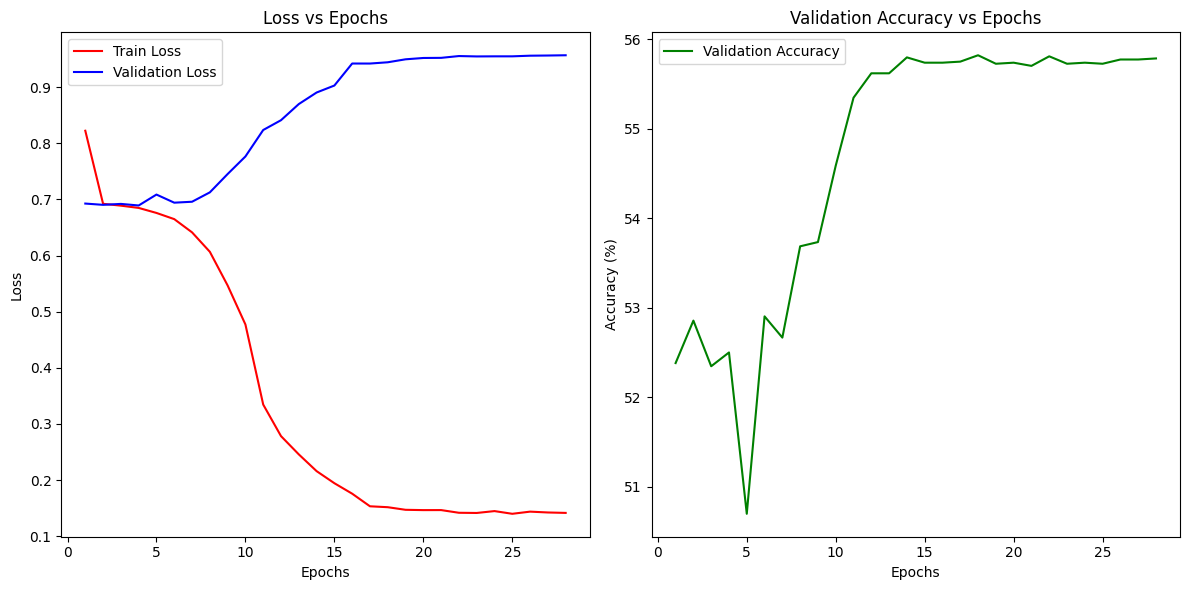

In [28]:
# --- 訓練過程圖 ---
# 繪製訓練過程中的損失和準確度變化圖
plt.figure(figsize=(12, 6))

# 損失圖
plt.subplot(1, 2, 1)
plt.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label="Train Loss", color="red")
plt.plot(range(1, len(history['val_loss']) + 1), history['val_loss'], label="Validation Loss", color="blue")
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# 準確度圖
plt.subplot(1, 2, 2)
plt.plot(range(1, len(history['val_acc']) + 1), history['val_acc'], label="Validation Accuracy", color="green")
plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()